In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow.keras as keras
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [2]:
DATA_DIR = Path(".")  

spectra = np.load(DATA_DIR / "spectrums.npy")
params = pd.read_csv(DATA_DIR / "FM_Parameter_Table.csv")
aux = pd.read_csv(DATA_DIR / "AuxillaryTable.csv")

# spectrums shape: (examples, wavelengths, 4)
wavelength_grid = spectra[:, :, 0]
spectrum = spectra[:, :, 1]
uncertainty = spectra[:, :, 2]
bin_width = spectra[:, :, 3]


# Labels: inspect columns first, then choose target columns
print(params.columns)
print(aux.columns)
print(spectra.shape, params.shape, aux.shape)

Index(['Unnamed: 0', 'planet_ID', 'planet_radius', 'planet_temp', 'log_H2O',
       'log_CO2', 'log_CO', 'log_CH4', 'log_NH3'],
      dtype='str')
Index(['planet_ID', 'star_distance', 'star_mass_kg', 'star_radius_m',
       'star_temperature', 'planet_mass_kg', 'planet_orbital_period',
       'planet_distance', 'planet_surface_gravity'],
      dtype='str')
(41423, 52, 4) (41423, 9) (41423, 9)


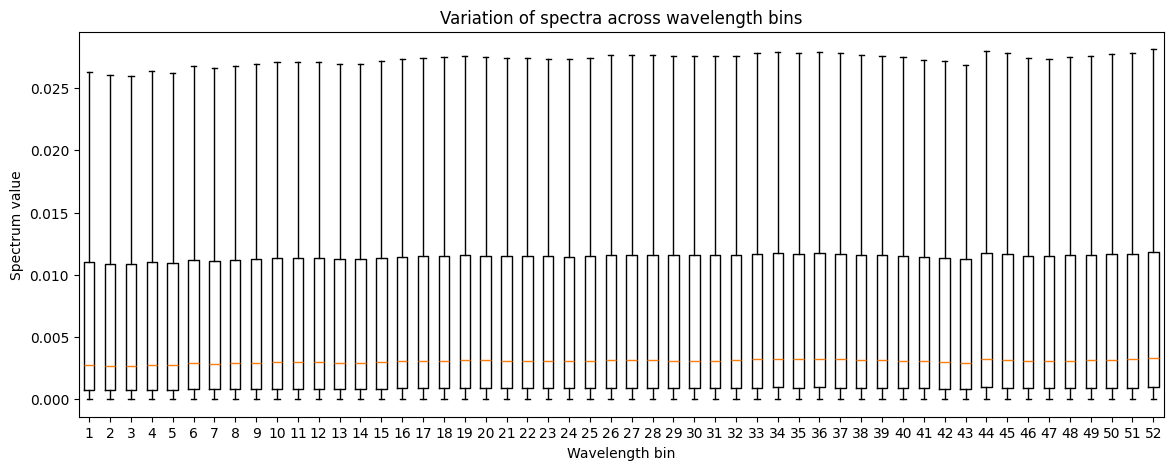

In [3]:
X = spectra[:, :, 1]   # shape: (41423, 52)

plt.figure(figsize=(14, 5))
plt.boxplot(X, showfliers=False)
plt.xlabel("Wavelength bin")
plt.ylabel("Spectrum value")
plt.title("Variation of spectra across wavelength bins")
plt.show()

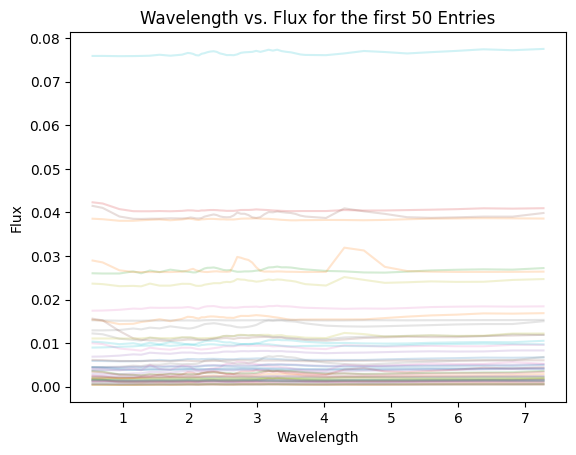

In [4]:
wave = spectra[0,:,0]

for i in range(50):
    plt.plot(wave, spectra[i,:,1], alpha=0.2)

plt.xlabel("Wavelength")
plt.ylabel("Flux")
plt.title("Wavelength vs. Flux for the first 50 Entries")
plt.savefig("fig1.png")
plt.show()

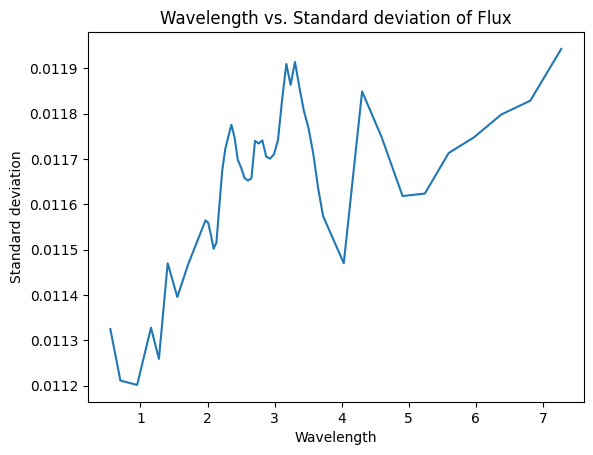

In [33]:
flux = spectra[:,:,1]

std = np.std(flux, axis=0)

plt.plot(wave, std)
plt.xlabel("Wavelength")
plt.ylabel("Standard deviation")
plt.title("Wavelength vs. Standard deviation of Flux")
plt.savefig("fig2.png")
plt.show()

In [67]:
# Use the spectrum values as input features
target_cols = ["log_H2O", "log_CO2", "log_CO", "log_CH4", "log_NH3", "planet_radius", "planet_temp"]

X = spectra[:, :, 1].astype("float32")
y = params[target_cols].values.astype("float32")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.10, random_state=42)

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.20, random_state=42)

print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)
print(X_test.shape, y_test.shape)

(29824, 52) (29824, 7)
(7456, 52) (7456, 7)
(4143, 52) (4143, 7)


In [7]:
#normalize the input features
x_scaler = StandardScaler()
x_train_scaled = x_scaler.fit_transform(X_train)
x_val_scaled = x_scaler.transform(X_val)
x_test_scaled = x_scaler.transform(X_test)

y_scaler = StandardScaler()
y_train_scaled = y_scaler.fit_transform(y_train)
y_val_scaled = y_scaler.transform(y_val)
y_test_scaled = y_scaler.transform(y_test)
print(x_train_scaled.mean(), x_train_scaled.std())

3.148479e-10 1.0


In [8]:
X_train_cnn = x_train_scaled[..., np.newaxis]
X_val_cnn = x_val_scaled[..., np.newaxis]
X_test_cnn = x_test_scaled[..., np.newaxis]

print(X_train_cnn.shape)

(29824, 52, 1)


## A first CNN

In [9]:
import tensorflow as tf
from tensorflow.keras import layers, models

firstmodel = models.Sequential([
    
    layers.Conv1D(
        filters=128,
        kernel_size=5,
        activation='relu',
        input_shape=(52,1)),

    layers.MaxPooling1D(pool_size=2),

    layers.Conv1D(
        filters=128,
        kernel_size=5,
        activation='relu'
    ),

    layers.MaxPooling1D(pool_size=2),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),

    layers.Dense(7)  # 7 Targets
])

firstmodel.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

firstmodel.summary()

/opt/anaconda3/envs/astro_tf/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 48, 128)        │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 24, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 20, 128)        │        82,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 10, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 247,687 (967.53 KB)

 Trainable params: 247,687 (967.53 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = firstmodel.fit(
    X_train_cnn,
    y_train_scaled,
    validation_data=(X_val_cnn, y_val_scaled),
    epochs=100,
    batch_size=128,
    callbacks=[early_stop]
)

Epoch 1/100
233/233 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.8507 - mae: 0.7551 - val_loss: 0.7565 - val_mae: 0.7035
Epoch 2/100
233/233 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.6250 - mae: 0.6264 - val_loss: 0.5116 - val_mae: 0.5573
Epoch 3/100
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.4426 - mae: 0.5095 - val_loss: 0.3870 - val_mae: 0.4680
Epoch 4/100
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.3491 - mae: 0.4439 - val_loss: 0.3255 - val_mae: 0.4264
Epoch 5/100
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.2914 - mae: 0.4011 - val_loss: 0.2710 - val_mae: 0.3852
Epoch 6/100
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.2552 - mae: 0.3715 - val_loss: 0.2411 - val_mae: 0.3578
Epoch 7/100
233/233 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.2328 - mae: 0.3519 - val_loss: 0.2238 - val_mae: 0.3459
Epoch 8/100
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.2145 - mae: 0.3358 - val_loss: 0.2042 - val_mae: 0.3277
Epoch 9/100
233/233 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/

In [11]:
pred_scaled_1 = firstmodel.predict(X_test_cnn)

y_pred_1 = y_scaler.inverse_transform(pred_scaled_1)
y_true_1 = y_scaler.inverse_transform(y_test_scaled)

130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


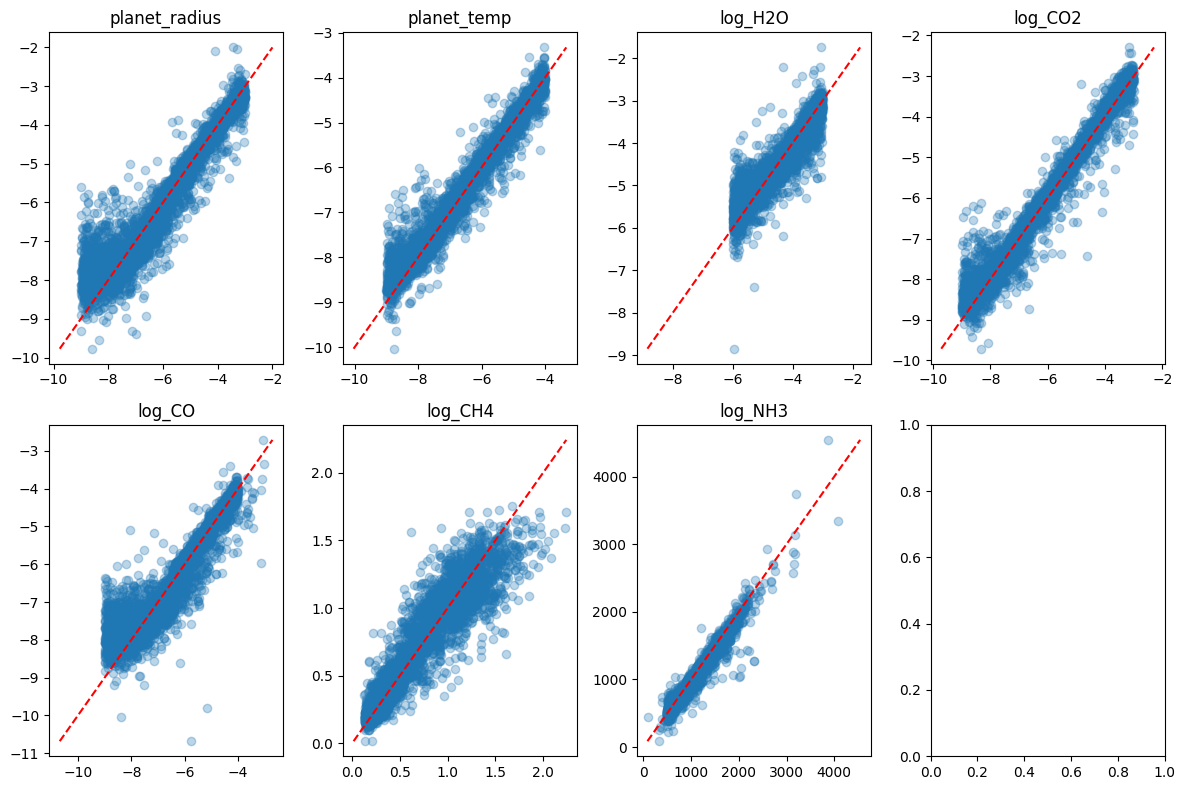

In [41]:
fig, axes = plt.subplots(2,4, figsize=(12,8))
axes = axes.ravel()

for i, label in enumerate(target_cols):

    axes[i].scatter(y_true_1[:,i], y_pred_1[:,i], alpha=0.3)

    mn = min(y_true_1[:,i].min(), y_pred_1[:,i].min())
    mx = max(y_true_1[:,i].max(), y_pred_1[:,i].max())

    axes[i].plot([mn,mx],[mn,mx],"r--")
    axes[i].set_title(label)

plt.tight_layout()
plt.savefig("fig3.png")
plt.show()

In [13]:
r2_1 = r2_score(y_true_1, y_pred_1)
r2_1

0.9098096489906311

In [97]:
mae_1 =  mean_absolute_error(y_true_1, y_pred_1)
mae_1

8.458139419555664

In [14]:
rmse_1 = np.sqrt(mean_squared_error(y_true_1, y_pred_1))
rmse_1

np.float64(35.00792669725851)

In [93]:
for i, label in enumerate(target_cols):

    mae = mean_absolute_error(y_true_1[:,i], y_pred_1[:,i])
    r2 = r2_score(y_true_1[:,i], y_pred_1[:,i])

    print(f"{label:15s}  MAE={mae:.3f}  R²={r2:.3f}")

log_H2O          MAE=0.347  R²=0.907
log_CO2          MAE=0.223  R²=0.948
log_CO           MAE=0.216  R²=0.862
log_CH4          MAE=0.220  R²=0.962
log_NH3          MAE=0.352  R²=0.865
planet_radius    MAE=0.108  R²=0.880
planet_temp      MAE=57.741  R²=0.946


## Adding an additional Convolutional Layer

In [16]:
import tensorflow as tf
from tensorflow.keras import layers, models

model_2 = models.Sequential([
    
    layers.Conv1D(
        filters=32,
        kernel_size=5,
        activation='relu',
        input_shape=(52,1)),

    layers.Conv1D(
        filters=64,
        kernel_size=5,
        activation='relu'),
    
    layers.MaxPooling1D(pool_size=2),

    layers.Conv1D(
        filters=128,
        kernel_size=5,
        activation='relu'
    ),

    layers.MaxPooling1D(pool_size=2),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),

    layers.Dense(7)  # 7 Targets
])

model_2.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

model_2.summary()

/opt/anaconda3/envs/astro_tf/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 48, 32)         │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 44, 64)         │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 22, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 18, 128)        │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 9, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 200,071 (781.53 KB)

 Trainable params: 200,071 (781.53 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model_2.fit(
    X_train_cnn,
    y_train_scaled,
    validation_data=(X_val_cnn, y_val_scaled),
    epochs=100,
    batch_size=128,
    callbacks=[early_stop]
)

Epoch 1/100
233/233 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.8323 - mae: 0.7456 - val_loss: 0.6349 - val_mae: 0.6368
Epoch 2/100
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.4865 - mae: 0.5374 - val_loss: 0.3918 - val_mae: 0.4747
Epoch 3/100
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.3407 - mae: 0.4371 - val_loss: 0.3085 - val_mae: 0.4143
Epoch 4/100
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.2860 - mae: 0.3961 - val_loss: 0.2638 - val_mae: 0.3763
Epoch 5/100
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.2473 - mae: 0.3659 - val_loss: 0.2363 - val_mae: 0.3561
Epoch 6/100
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.2244 - mae: 0.3463 - val_loss: 0.2094 - val_mae: 0.3324
Epoch 7/100
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.2004 - mae: 0.3248 - val_loss: 0.1893 - val_mae: 0.3158
Epoch 8/100
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1877 - mae: 0.3126 - val_loss: 0.1777 - val_mae: 0.3045
Epoch 9/100
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/

In [18]:
pred_scaled_2 = model_2.predict(X_test_cnn)

y_pred_2 = y_scaler.inverse_transform(pred_scaled_2)
y_true_2 = y_scaler.inverse_transform(y_test_scaled)

130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


In [19]:
r2_2 = r2_score(y_true_2, y_pred_2)
r2_2

0.9186038970947266

In [98]:
mae_2 =  mean_absolute_error(y_true_2, y_pred_2)
mae_2

6.839754581451416

In [20]:
rmse_2 = np.sqrt(mean_squared_error(y_true_2, y_pred_2))
rmse_2

np.float64(28.624762255085304)

In [94]:
for i, label in enumerate(target_cols):

    mae = mean_absolute_error(y_true_2[:,i], y_pred_2[:,i])
    r2 = r2_score(y_true_2[:,i], y_pred_2[:,i])

    print(f"{label:15s}  MAE={mae:.3f}  R²={r2:.3f}")

log_H2O          MAE=0.330  R²=0.919
log_CO2          MAE=0.225  R²=0.949
log_CO           MAE=0.201  R²=0.884
log_CH4          MAE=0.205  R²=0.968
log_NH3          MAE=0.350  R²=0.870
planet_radius    MAE=0.108  R²=0.878
planet_temp      MAE=46.458  R²=0.964


## Planetary Distance hinzufügen:

In [45]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

target_cols_aux = [
    "planet_radius", "planet_temp",
    "log_H2O", "log_CO2", "log_CO", "log_CH4", "log_NH3"
]

# Spectrum input: 52 wavelength bins
X_spectrum = spectra[:, :, 1].astype("float32")

# Extra auxiliary input: orbital distance
aux_cols = ["planet_distance"]

# Match aux rows to params rows by planet_ID
aux_ordered = aux.set_index("planet_ID").loc[params["planet_ID"], aux_cols]
X_aux = aux_ordered.values.astype("float32")

# Final input: 52 spectrum bins + 1 auxiliary feature
X = np.hstack([X_spectrum, X_aux])

y = params[target_cols_aux].values.astype("float32")

# Split
x_train, x_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42
)

x_val, x_test, y_val, y_test = train_test_split(
    x_temp, y_temp, test_size=0.50, random_state=42
)

# Standardize X
x_scaler = StandardScaler()

x_train_aux = x_scaler.fit_transform(x_train)
x_val_aux = x_scaler.transform(x_val)
x_test_aux = x_scaler.transform(x_test)

# Standardize y
y_scaler = StandardScaler()

y_train_aux = y_scaler.fit_transform(y_train)
y_val_aux = y_scaler.transform(y_val)
y_test_aux = y_scaler.transform(y_test)


In [22]:
model_aux = models.Sequential([
    
    layers.Conv1D(
        filters=32,
        kernel_size=5,
        activation='relu',
        input_shape=(52,1)),

    layers.Conv1D(
        filters=64,
        kernel_size=5,
        activation='relu'),
    
    layers.MaxPooling1D(pool_size=2),

    layers.Conv1D(
        filters=128,
        kernel_size=5,
        activation='relu'
    ),

    layers.MaxPooling1D(pool_size=2),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),

    layers.Dense(7)  # 7 Targets
])

model_aux.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

model_aux.summary()

/opt/anaconda3/envs/astro_tf/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_5 (Conv1D)               │ (None, 48, 32)         │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_6 (Conv1D)               │ (None, 44, 64)         │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 22, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ (None, 18, 128)        │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_5 (MaxPooling1D)  │ (None, 9, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 200,071 (781.53 KB)

 Trainable params: 200,071 (781.53 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model_aux.fit(
    x_train_scaled,
    y_train_scaled,
    validation_data=(x_val_scaled, y_val_scaled),
    epochs=100,
    batch_size=128,
    callbacks=[early_stop]
)


Epoch 1/100
233/233 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.8136 - mae: 0.7345 - val_loss: 0.6222 - val_mae: 0.6230
Epoch 2/100
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.4593 - mae: 0.5208 - val_loss: 0.3511 - val_mae: 0.4433
Epoch 3/100
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.3072 - mae: 0.4136 - val_loss: 0.2814 - val_mae: 0.3961
Epoch 4/100
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.2531 - mae: 0.3712 - val_loss: 0.2372 - val_mae: 0.3578
Epoch 5/100
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.2201 - mae: 0.3432 - val_loss: 0.2068 - val_mae: 0.3313
Epoch 6/100
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.2004 - mae: 0.3255 - val_loss: 0.1939 - val_mae: 0.3207
Epoch 7/100
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1846 - mae: 0.3109 - val_loss: 0.1781 - val_mae: 0.3056
Epoch 8/100
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1748 - mae: 0.3008 - val_loss: 0.1659 - val_mae: 0.2938
Epoch 9/100
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/

In [24]:
pred_scaled_aux = model_aux.predict(x_test_scaled)

y_pred_aux = y_scaler.inverse_transform(pred_scaled_aux)
y_true_aux = y_scaler.inverse_transform(y_test_scaled)

130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


In [25]:
r2_aux = r2_score(y_true_aux, y_pred_aux)
r2_aux

0.9222621321678162

In [96]:
mae_aux =  mean_absolute_error(y_true_aux, y_pred_aux)
mae_aux

8.009570121765137

In [26]:
rmse_aux = np.sqrt(mean_squared_error(y_true_aux, y_pred_aux))
rmse_aux

np.float64(30.971772170586537)

In [95]:
for i, label in enumerate(target_cols_aux):

    mae = mean_absolute_error(y_true_aux[:,i], y_pred_aux[:,i])
    r2 = r2_score(y_true_aux[:,i], y_pred_aux[:,i])

    print(f"{label:15s}  MAE={mae:.3f}  R²={r2:.3f}")

planet_radius    MAE=0.087  R²=0.919
planet_temp      MAE=54.657  R²=0.958
log_H2O          MAE=0.378  R²=0.893
log_CO2          MAE=0.163  R²=0.970
log_CO           MAE=0.201  R²=0.875
log_CH4          MAE=0.418  R²=0.879
log_NH3          MAE=0.164  R²=0.963


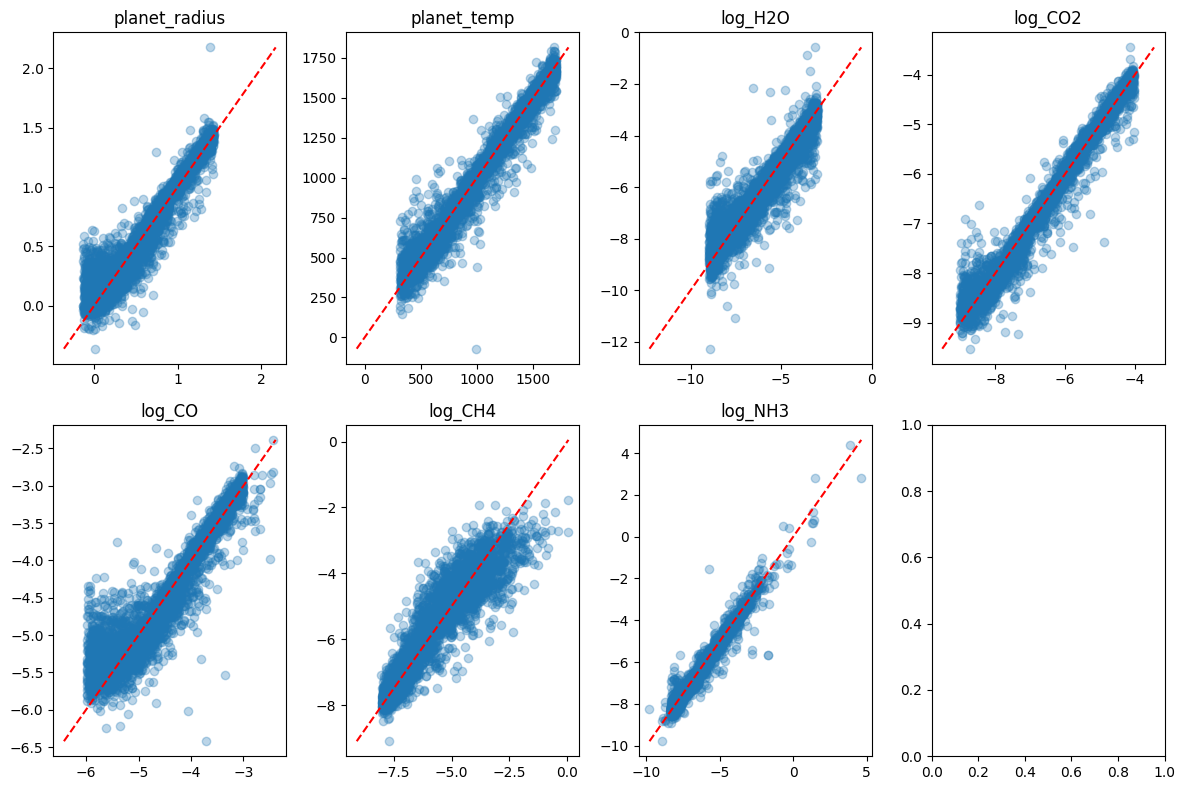

In [40]:
fig, axes = plt.subplots(2,4, figsize=(12,8))
axes = axes.ravel()

for i, label in enumerate(target_cols):

    axes[i].scatter(y_true_aux[:,i], y_pred_aux[:,i], alpha=0.3)

    mn = min(y_true_aux[:,i].min(), y_pred_aux[:,i].min())
    mx = max(y_true_aux[:,i].max(), y_pred_aux[:,i].max())

    axes[i].plot([mn,mx],[mn,mx],"r--")
    axes[i].set_title(label)

plt.tight_layout()
plt.savefig("fig4.png")
plt.show()

In [100]:
print("\nModel Performance Summary")
print("-" * 50)
print(f"{'Model':<15} {'R²':>10} {'MAE':>12} {'RMSE':>12}")
print("-" * 50)
print(f"{'First CNN':<15} {r2_1:>10.4f} {mae_1:>12.4f} {rmse_1:>12.4f}")
print(f"{'Second CNN':<15} {r2_2:>10.4f} {mae_2:>12.4f} {rmse_2:>12.4f}")
print(f"{'CNN + Aux':<15} {r2_aux:>10.4f} {mae_aux:>12.4f} {rmse_aux:>12.4f}")
print("-" * 50)


Model Performance Summary
--------------------------------------------------
Model                   R²          MAE         RMSE
--------------------------------------------------
First CNN           0.9098       8.4581      35.0079
Second CNN          0.9186       6.8398      28.6248
CNN + Aux           0.9223       8.0096      30.9718
--------------------------------------------------


In [99]:
print("Summary:")
print("first model: ", r2_1, mae_1, rmse_1)
print("second model: ", r2_2, mae_2, rmse_2)
print("aux model: ", r2_aux, mae_aux, rmse_aux)

Summary:
first model:  0.9098096489906311 8.458139419555664 35.00792669725851
second model:  0.9186038970947266 6.839754581451416 28.624762255085304
aux model:  0.9222621321678162 8.009570121765137 30.971772170586537
